In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
df = pd.read_csv("/home/abijithpersonal/Documents/Recap_ML/paper_three/module10/data/employees_practice.csv")

In [61]:
df.shape

(10, 7)

In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   employee_id       10 non-null     int64  
 1   name              10 non-null     str    
 2   department        10 non-null     str    
 3   age               7 non-null      float64
 4   experience_years  8 non-null      float64
 5   salary            8 non-null      float64
 6   rating            8 non-null      str    
dtypes: float64(3), int64(1), str(3)
memory usage: 692.0 bytes


In [63]:
df.isnull().sum()

employee_id         0
name                0
department          0
age                 3
experience_years    2
salary              2
rating              2
dtype: int64

In [64]:
df = df.drop_duplicates()

In [65]:
df

,employee_id,name,department,age,experience_years,salary,rating
0,101,Anu Nair,sales,29.0,4.0,42000.0,Good
1,102,Rahul Menon,IT,NaN,9.0,58000.0,Excellent
2,103,Priya Das,HR,41.0,NaN,NaN,Average
3,104,Arjun Iyer,sales,35.0,6.0,51000.0,NaN
4,105,Meera Pillai,IT,NaN,3.0,39000.0,Good
5,106,Vishnu Kumar,Finance,38.0,NaN,62000.0,Excellent
6,107,Divya Varma,hr,27.0,2.0,NaN,Average
7,108,Kiran Thomas,IT,45.0,15.0,71000.0,NaN
8,109,Sneha Jose,FINANCE,NaN,5.0,45500.0,Good
9,110,Rohit Raj,Sales,33.0,7.0,48000.0,Excellent


In [66]:
df["age"] = df["age"].fillna(df["age"].median())

In [67]:
df["experience_years"] = df["experience_years"].fillna(df["experience_years"].median())

In [68]:
df.dropna(subset=["salary"], inplace=True)

In [69]:
df["salary"].corr(df["age"])

np.float64(0.8291746462235694)

In [70]:
corr_matrix = df.corr(numeric_only=True)

<Axes: >

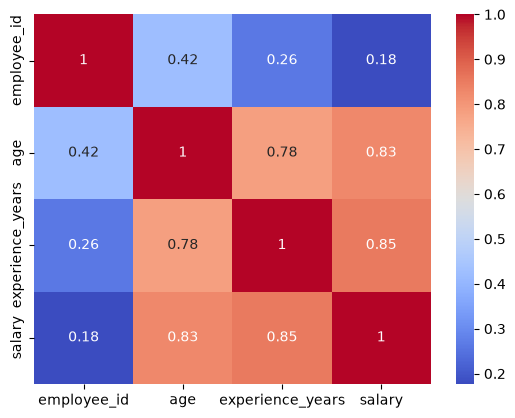

In [71]:
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

In [78]:
df

,age,experience_years,salary,department_finance,department_it,department_sales
0,-1.551459,-0.795619,42000.0,0,0,1
1,-0.146364,0.618815,58000.0,0,1,0
3,-0.146364,-0.229846,51000.0,0,0,1
4,-0.146364,-1.078506,39000.0,0,1,0
5,0.556184,-0.371289,62000.0,1,0,0
7,2.195462,2.316137,71000.0,0,1,0
8,-0.146364,-0.512733,45500.0,1,0,0
9,-0.614729,0.053041,48000.0,0,0,1


In [73]:
df = df.drop(columns=["employee_id","name", "rating"])

In [74]:
df["department"] = df["department"].str.strip().str.lower()

In [75]:
df = pd.get_dummies(df, columns=["department"], dtype=int)

In [76]:
from sklearn.preprocessing import StandardScaler

scalar = StandardScaler()

df[["experience_years"]] = scalar.fit_transform(df[["experience_years"]])
df[["age"]] = scalar.fit_transform(df[["age"]])

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

x = df.drop(columns=["salary"], inplace=True)
y = df["salary"]

x_train, y_train, x_test, y_test = train_test_split(x, y, train_size=.80, random_state=40)
